In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm   
import pandas_ta as ta
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model
sns.set_theme(style="whitegrid")
import re
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split
import joblib


In [56]:
df = pd.read_csv("btc_usdc_30m_1year_hyperliquid.csv")#("btc_usdc_15m_1year.csv")

In [57]:
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.set_index('Open time')

ohlc_dict = {                                                                                                             
    'Open': 'first',                                                                                                    
    'High': 'max',                                                                                                       
    'Low': 'min',                                                                                                        
    'Close': 'last',                                                                                                    
    'Volume': 'sum',
}

df = df.resample('30min', closed='left', label='left').apply(ohlc_dict)

In [58]:
df[df.index >= '2026-04-12 21:30:00'].head()

,Open,High,Low,Close,Volume
Open time,,,,,
2026-04-12 21:30:00,71267.0,71332.0,71171.0,71331.0,175.44249
2026-04-12 22:00:00,71332.0,71332.0,70523.0,70628.0,1768.89437
2026-04-12 22:30:00,70628.0,70904.0,70450.0,70883.0,1038.15066
2026-04-12 23:00:00,70883.0,70883.0,70555.0,70685.0,796.87852
2026-04-12 23:30:00,70684.0,70766.0,70524.0,70705.0,776.66664


In [ ]:
df.sort_index(inplace=True)

df['sma_20'] = df.ta.sma(length=20)
df['sma_50'] = df.ta.sma(length=50)

df['rsi_14'] = df.ta.rsi(length=14)
df.ta.macd(append=True)

df['close_log_return'] = np.log(df['Close']/df['Close'].shift())
df['close_log_return_lag_1'] = df['close_log_return'].shift()
df['close_log_return_lag_2'] = df['close_log_return'].shift(2)
df['close_log_return_lag_3'] = df['close_log_return'].shift(3)
# Represents the 'Real Body' of the candle
df['body_size'] = (df['Close'] - df['Open']).abs()


df = df.dropna()

Text(0.5, 1.0, 'Correlation Heatmap')

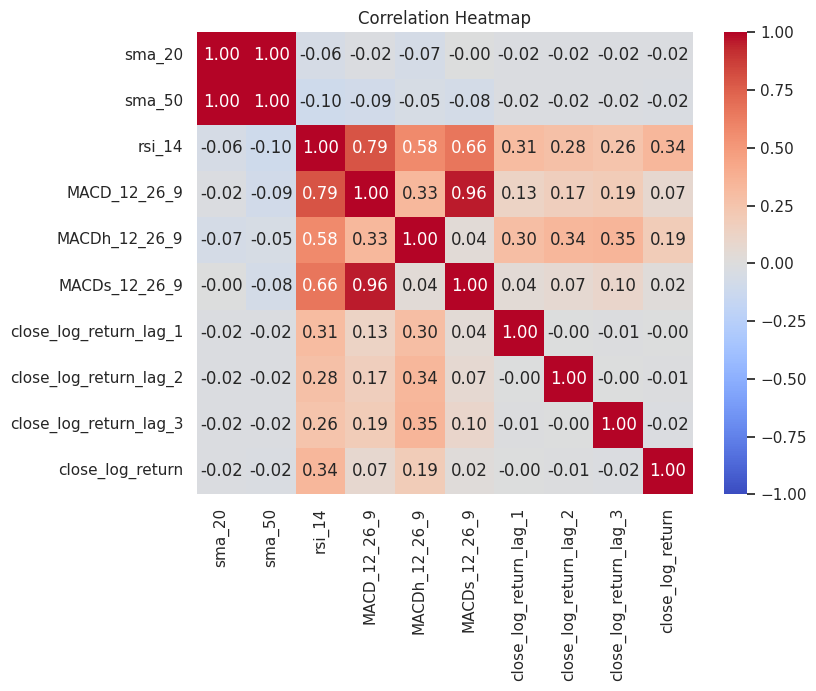

In [33]:


corr_matrix = df[['sma_20', 'sma_50', 'rsi_14',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 
       'close_log_return_lag_1', 'close_log_return_lag_2',
       'close_log_return_lag_3', 'close_log_return']].corr()

# Create Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")



In [34]:
df = df[df.index >= '2026-04-19 13:30:00']

In [35]:
X = df[['rsi_14', 'MACDh_12_26_9', 'MACD_12_26_9', 'close_log_return_lag_1', 
'close_log_return_lag_2', 'close_log_return_lag_3']]
       
"""X = df_all[['rsi_14',
       'MACD_12_26_9', 'MACDh_12_26_9',
       'close_log_return_lag_1']]"""

y = df[['close_log_return']]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% for testing, adjust as needed (e.g., 0.3 for 30%)
    shuffle=False  # CRITICAL: Prevents random shuffling to preserve time order
)

#model = sm.OLS(y_train,X_train)
#results = model.fit()
#model = linear_model.LinearRegression()
#results = model.fit(X_train, y_train)
results = joblib.load('model.joblib')
#y_test['predict'] = results.predict(X_test.values)
#y_train['predict'] = results.predict(X_train.values)

y_test['predict'] = results.predict(X_test)
y_train['predict'] = results.predict(X_train)


In [36]:
y_test['predict'] = results.predict(X_test.values)
y_train['predict'] = results.predict(X_train.values)

/home/ubuntu/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/ubuntu/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


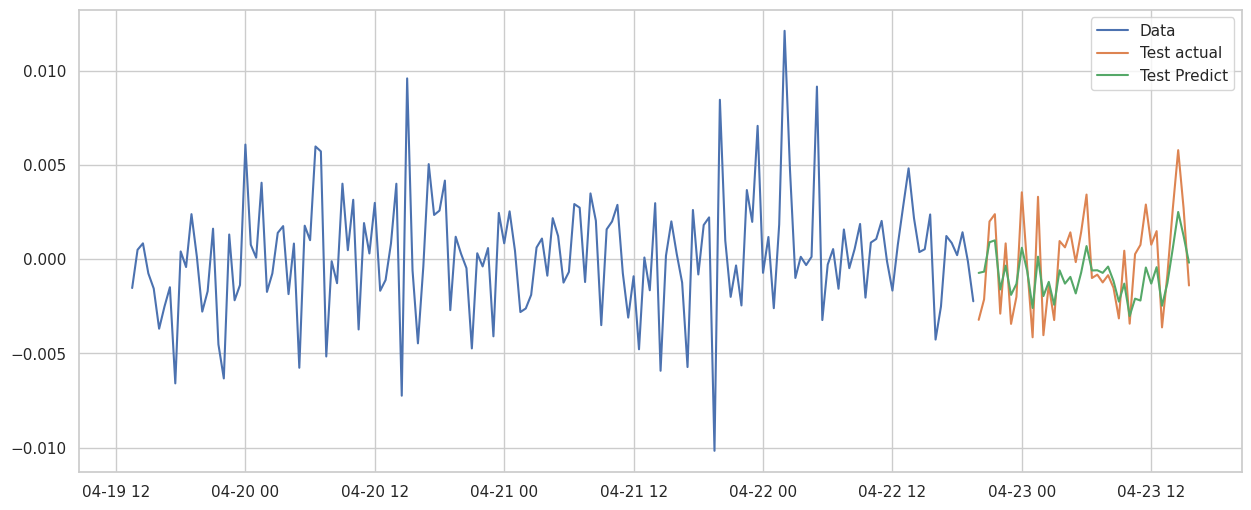

In [37]:


plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train['close_log_return'], label="Data")
plt.plot(y_test.index, y_test['close_log_return'], label="Test actual")
plt.plot(y_test.index, y_test['predict'], label="Test Predict")
plt.legend()



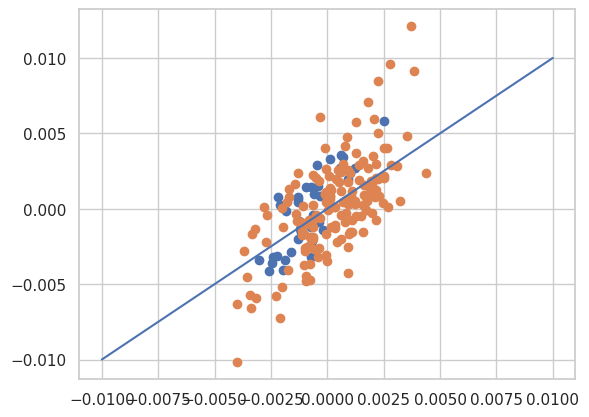

In [38]:
plt.scatter(y_test['predict'], y_test['close_log_return'], label="Test actual")
plt.scatter(y_train['predict'], y_train['close_log_return'], label="Test actual")
plt.plot([-0.01,0.01], [-0.01,0.01])

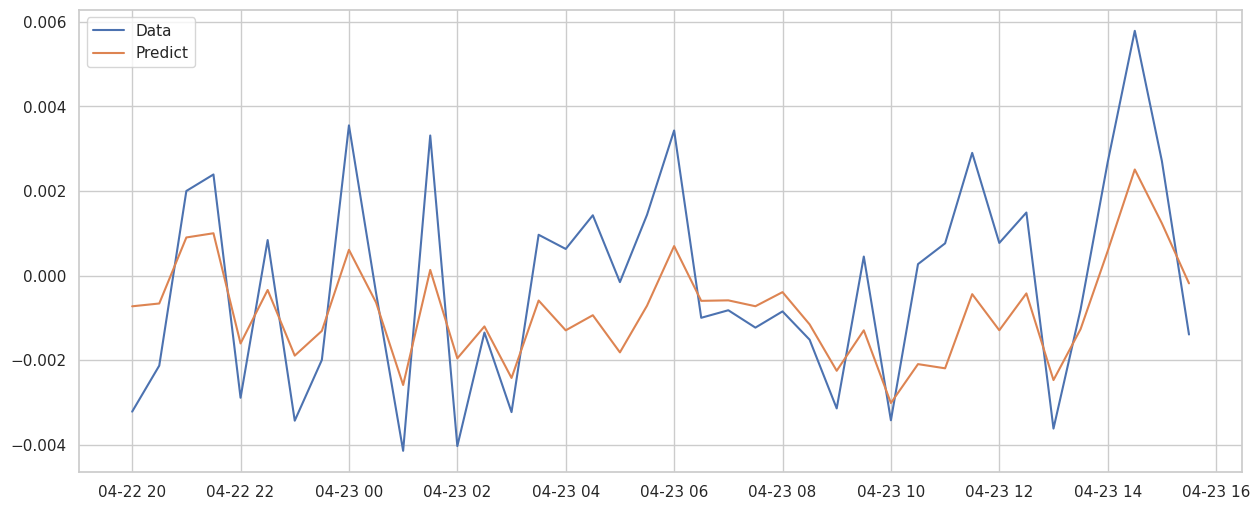

In [39]:


plt.figure(figsize=(15, 6))
plt.plot(y_test.index, y_test['close_log_return'], label="Data")
plt.plot(y_test.index, y_test['predict'], label='Predict')
plt.legend()



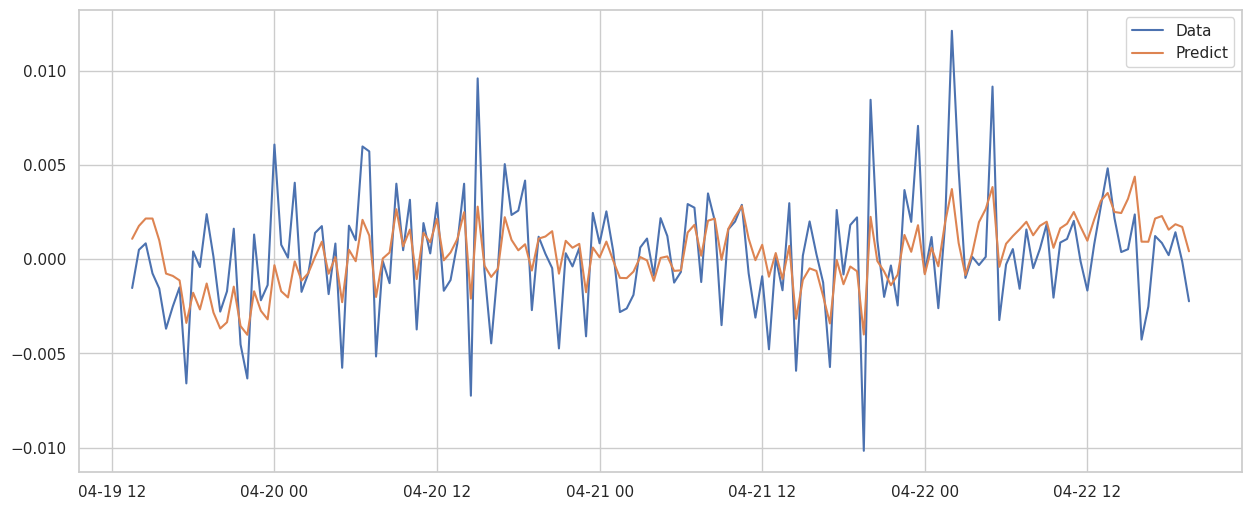

In [40]:


plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train['close_log_return'],label='Data')
plt.plot(y_train.index, y_train['predict'],label='Predict')
plt.legend()



In [26]:


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit

estimator = LinearRegression()
# Use TimeSeriesSplit to ensure data leakage from future to past does not occur
tscv = TimeSeriesSplit(n_splits=5) # Adjust n_splits as needed

# 3. Calculate the learning curve data
# Use a relevant scoring metric for regression, e.g., 'neg_mean_squared_error' or 'r2'
train_sizes, train_scores, test_scores = learning_curve(
    estimator,
    X,
    y,
    cv=tscv,
    scoring='neg_mean_squared_error', # Use 'neg_mean_squared_error' for a 'loss' perspective
    train_sizes=np.linspace(0.1, 1.0, 10), # Vary the proportion of training samples
    n_jobs=-1 # Use all available cores
)



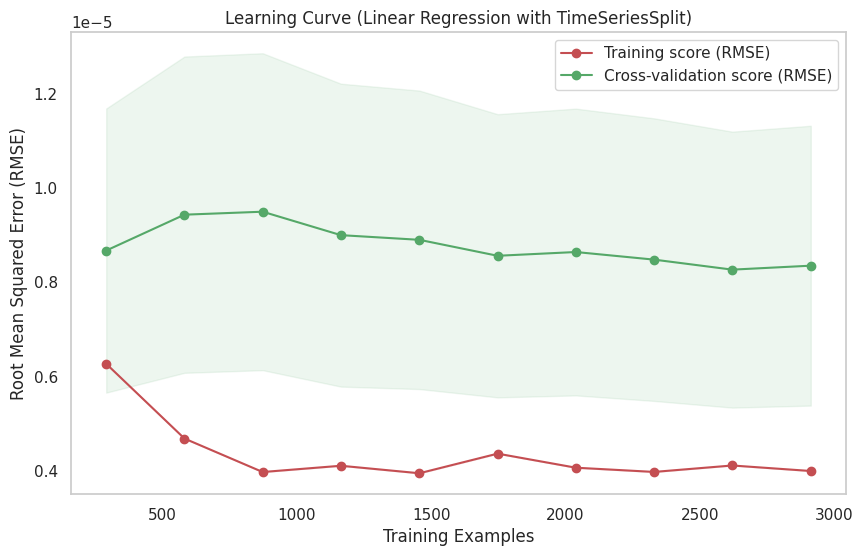

In [27]:


train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 5. Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Linear Regression with TimeSeriesSplit)")
plt.xlabel("Training Examples")
plt.ylabel("Root Mean Squared Error (RMSE)") # Label the metric correctly

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score (RMSE)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score (RMSE)")

plt.legend(loc="best")
plt.grid()



In [41]:
y_test['won'] = np.sign(y_test['predict']) == np.sign(y_test['close_log_return'])
y_test['signal'] = np.sign(y_test['predict'])
y_test['trade_log_return_predict'] = y_test['signal']*y_test['close_log_return']
y_test['equity_curve_predict'] = y_test['trade_log_return_predict'].cumsum()


In [42]:
maker_fee = 0.0001
taker_fee = 0.00045

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

y_test['fees'] = roundtrip_fee_log
y_test['trade_log_return_predict_fees'] = y_test['trade_log_return_predict'] + y_test['fees']
y_test['equity_curve_predict_fees'] = y_test['trade_log_return_predict_fees'].cumsum()

In [43]:


df_trades = pd.concat([X_test, y_test], axis=1)
df_trades = pd.concat([df[['Open', 'Close']], df_trades], axis=1, join='inner')



In [44]:

capital = 1000
ratio = 0.01 # you could experiment with different ratios like kelly criterion
trade_value = ratio * capital
df_trades['entry_trace'] = trade_value

df_trades['exit_trade_value'] = df_trades['entry_trace']*np.exp(df_trades['trade_log_return_predict'])
df_trades['trade_qty'] = df_trades['entry_trace'] / df_trades['Open'] 
df_trades['signed_trade_qty'] = df_trades['trade_qty'] * df_trades['signal']



In [45]:
df_trades['trade_gross_pnl'] = df_trades['exit_trade_value'] - df_trades['entry_trace']

In [46]:
df_trades['taker_fee'] = df_trades['entry_trace'] * taker_fee + df_trades['exit_trade_value'] * taker_fee

In [47]:
df_trades['trade_net_taker_pnl'] = df_trades['trade_gross_pnl'] - df_trades['taker_fee'] 
df_trades['trade_net_taker_equity_curve'] = df_trades['trade_net_taker_pnl'].cumsum() + capital

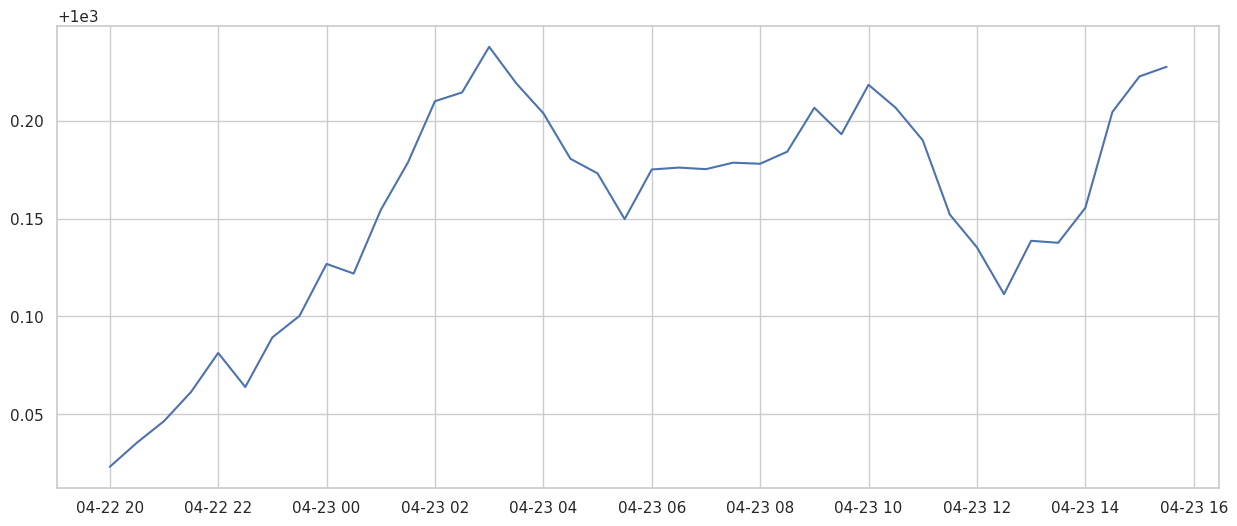

In [48]:
plt.figure(figsize=(15, 6))
plt.plot(df_trades.index, df_trades['trade_net_taker_equity_curve'], label="Data")


In [120]:
import joblib
joblib.dump(model, 'model.joblib')


['model.joblib']